In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
pip install pydot graphviz

In [3]:
!pip install -q spectral einops thop

import os, time, zipfile, gc
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import tensorflow as tf
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import cohen_kappa_score, precision_recall_fscore_support
from tensorflow.keras.utils import to_categorical
import spectral

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 7.8 MB/s eta 0:00:00
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
# ===============================================================
# CONFIG (same style as LhSSN)
# ==============================================================

dataset = 'IP'
windowSize = 25
n_components_pca = 30 # Renamed K to n_components_pca to avoid conflict
epochs = 100
batch_size = 256
learning_rate = 0.001

split_mode = "ratio"          # ratio / count

train_ratio = 0.05           # if ratio
samples_per_class = 15       # if count

results_folder = "LhSSN_SA_Module_Output"
os.makedirs(results_folder, exist_ok=True)

base = "/content/drive/MyDrive/Colab Notebooks/dataset/"

# ===============================================================
# DATA LOADING
# ==============================================================

def loadData(name):
    if name == 'IP':
        X = sio.loadmat(base+'Indian_pines_corrected.mat')['indian_pines_corrected']
        y = sio.loadmat(base+'Indian_pines_gt.mat')['indian_pines_gt']
    elif name == 'SA':
        X = sio.loadmat(base+'Salinas_corrected.mat')['salinas_corrected']
        y = sio.loadmat(base+'Salinas_gt.mat')['salinas_gt']
    elif name == 'PU':
        X = sio.loadmat(base+'PaviaU.mat')['paviaU']
        y = sio.loadmat(base+'PaviaU_gt.mat')['paviaU_gt']
    elif name == 'Ho':
        X = sio.loadmat(base+'Houston.mat')['houston']
        y = sio.loadmat(base+'Houston_gt.mat')['houston_gt']
    elif name == 'Bo':
        X = sio.loadmat(base+'Botswana.mat')['Botswana']
        y = sio.loadmat(base+'Botswana_gt.mat')['Botswana_gt']
    elif name == 'KSC':
        X = sio.loadmat(base+'KSC.mat')['KSC']
        y = sio.loadmat(base+'KSC_gt.mat')['KSC_gt']
    return X, y
# ===============================================================
# PCA
# ==============================================================

def applyPCA(X, numComponents):
    reshaped = X.reshape(-1, X.shape[2])
    pca = PCA(n_components=numComponents, whiten=True)
    Xp = pca.fit_transform(reshaped)
    return Xp.reshape(X.shape[0], X.shape[1], numComponents)

# ===============================================================
# PATCH EXTRACTION
# ==============================================================

def padWithZeros(X, margin):
    return np.pad(X, ((margin,margin),(margin,margin),(0,0)), mode='constant')

def createImageCubes(X, y, windowSize=25):
    margin = windowSize // 2
    zeroPaddedX = padWithZeros(X, margin)

    patches = []
    labels = []

    for r in range(margin, zeroPaddedX.shape[0]-margin):
        for c in range(margin, zeroPaddedX.shape[1]-margin):

            patch = zeroPaddedX[r-margin:r+margin+1,
                                c-margin:c+margin+1]

            label = y[r-margin, c-margin]

            if label > 0:
                patches.append(patch)
                labels.append(label-1)

    return np.array(patches), np.array(labels)

# ===============================================================
# SPLIT
# ==============================================================

def splitTrainTestSet(X, y):

    np.random.seed(42)

    train_idx = []
    test_idx = []

    for cls in np.unique(y):

        idx = np.where(y == cls)[0]
        np.random.shuffle(idx)

        if split_mode == "ratio":
            n_train = max(1, int(len(idx)*train_ratio))
        else:
            n_train = min(samples_per_class, len(idx)-1)

        train_idx.extend(idx[:n_train])
        test_idx.extend(idx[n_train:])

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

# ===============================================================
# LOAD DATA
# ==============================================================

X, y = loadData(dataset)
X = applyPCA(X, n_components_pca)
X, y = createImageCubes(X, y, windowSize)

Xtrain, Xtest, ytrain, ytest = splitTrainTestSet(X, y)

num_classes = len(np.unique(y))

ytrain_cat = to_categorical(ytrain, num_classes)
ytest_cat = to_categorical(ytest, num_classes)

print("Train:", Xtrain.shape)
print("Test :", Xtest.shape)


Train: (505, 25, 25, 30)
Test : (9744, 25, 25, 30)


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.utils import plot_model
from tensorflow.keras import backend as keras_backend # Renamed K to keras_backend


# =========================================================
# CHANNEL ATTENTION (SEA)
# =========================================================

def channel_attention(x, ratio=8):

    channel = x.shape[-1]

    avg_pool = layers.GlobalAveragePooling2D()(x)
    max_pool = layers.GlobalMaxPooling2D()(x)

    avg_pool = layers.Reshape((1, 1, channel))(avg_pool)
    max_pool = layers.Reshape((1, 1, channel))(max_pool)

    shared_dense_1 = layers.Dense(
        max(channel // ratio, 4),
        activation='relu',
        use_bias=True
    )

    shared_dense_2 = layers.Dense(
        channel,
        activation='sigmoid',
        use_bias=True
    )

    avg_out = shared_dense_2(shared_dense_1(avg_pool))
    max_out = shared_dense_2(shared_dense_1(max_pool))

    attention = layers.Add()([avg_out, max_out])

    return layers.Multiply()([x, attention])


# =========================================================
# SPATIAL ATTENTION (SAA)
# =========================================================

def spatial_attention(x):

    avg_pool = layers.Lambda(
        lambda z: keras_backend.mean(z, axis=-1, keepdims=True) # Used keras_backend
    )(x)

    max_pool = layers.Lambda(
        lambda z: keras_backend.max(z, axis=-1, keepdims=True) # Used keras_backend
    )(x)

    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])

    attention = layers.Conv2D(
        filters=1,
        kernel_size=7,
        padding='same',
        activation='sigmoid',
        use_bias=False
    )(concat)

    return layers.Multiply()([x, attention])


# =========================================================
# STRIP DEPTHWISE CONV BLOCK
# =========================================================

def strip_depthwise_block(x):

    shortcut = x

    # horizontal strip
    x = layers.DepthwiseConv2D(
        kernel_size=(1, 3),
        padding='same',
        use_bias=False
    )(x)

    # vertical strip
    x = layers.DepthwiseConv2D(
        kernel_size=(3, 1),
        padding='same',
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # lightweight residual
    x = layers.Add()([shortcut, x])

    return x


# =========================================================
# MSD-CONV
# Proper paper implementation
# =========================================================

def msd_conv(x, kernel_size):

    """
    According to paper:

    3x3 -> 1 stacked strip block
    5x5 -> 2 stacked strip blocks
    7x7 -> 3 stacked strip blocks
    """

    if kernel_size == 3:
        num_blocks = 1

    elif kernel_size == 5:
        num_blocks = 2

    elif kernel_size == 7:
        num_blocks = 3

    else:
        raise ValueError("kernel_size must be 3,5,7")

    shortcut = x

    for _ in range(num_blocks):
        x = strip_depthwise_block(x)

    # multiscale fusion
    x = layers.Concatenate()([shortcut, x])

    return x


# =========================================================
# SCALE ATTENTION
# =========================================================

def scale_attention(x, ratio=8):

    channel = x.shape[-1]

    squeeze = layers.GlobalAveragePooling2D()(x)

    excitation = layers.Dense(
        max(channel // ratio, 4),
        activation='relu'
    )(squeeze)

    excitation = layers.Dense(
        channel,
        activation='sigmoid'
    )(excitation)

    excitation = layers.Reshape((1, 1, channel))(excitation)

    return layers.Multiply()([x, excitation])


# =========================================================
# PG-CONV
# =========================================================

def pg_conv(x, filters, groups=4):

    x = layers.Conv2D(
        filters=filters,
        kernel_size=1,
        padding='same',
        groups=groups,
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    return x


# =========================================================
# MSS-CONV BLOCK
# =========================================================

def mss_conv_block(
        x,
        filters,
        kernel_size,
        dropout_rate=0.2):

    # SEA
    x = channel_attention(x)

    # SAA
    x = spatial_attention(x)

    # dropout
    x = layers.Dropout(dropout_rate)(x)

    # MSD-CONV
    x = msd_conv(x, kernel_size)

    # Scale Attention
    x = scale_attention(x)

    # SEA
    x = channel_attention(x)

    # SAA
    x = spatial_attention(x)

    # PG-CONV
    x = pg_conv(x, filters)

    return x


# =========================================================
# SEARCH SPACE CELL
# =========================================================

def search_space_cell(x, filters):

    # branch 1
    b1 = layers.MaxPooling2D(
        pool_size=3,
        strides=1,
        padding='same'
    )(x)

    # branch 2
    b2 = layers.AveragePooling2D(
        pool_size=3,
        strides=1,
        padding='same'
    )(x)

    # branch 3
    b3 = x

    # branch 4
    b4 = mss_conv_block(
        x,
        filters,
        kernel_size=3
    )

    # branch 5
    b5 = mss_conv_block(
        x,
        filters,
        kernel_size=5
    )

    # branch 6
    b6 = mss_conv_block(
        x,
        filters,
        kernel_size=7
    )

    out = layers.Concatenate()([
        b1, b2, b3, b4, b5, b6
    ])

    out = layers.Conv2D(
        filters,
        kernel_size=1,
        padding='same',
        activation='relu'
    )(out)

    return out


# =========================================================
# COMPLETE MODEL
# =========================================================

def build_l3m_model(
        input_shape=(27, 27, 103),
        num_classes_arg=num_classes, # Renamed parameter to avoid conflict with global num_classes
        filters=32):

    inputs = Input(shape=input_shape) # Corrected Input shape to use the passed input_shape argument

    # stem
    x = layers.Conv2D(
        filters,
        kernel_size=3,
        padding='same',
        activation='relu'
    )(inputs)

    # -----------------------------------------------------
    # CELL 1
    # -----------------------------------------------------
    x = search_space_cell(x, filters)

    # reduction
    x = layers.MaxPooling2D(2)(x)

    # -----------------------------------------------------
    # CELL 2
    # -----------------------------------------------------
    x = search_space_cell(x, filters * 2)

    # reduction
    x = layers.MaxPooling2D(2)(x)

    # classifier
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(
        num_classes_arg, # Used the renamed parameter
        activation='softmax'
    )(x)

    model = Model(inputs, outputs, name='L3M_MSSConv')

    return model


# =========================================================
# BUILD MODEL
# =========================================================
# Corrected the call to build_l3m_model to pass input_shape as a tuple
model = build_l3m_model(input_shape=(windowSize, windowSize, n_components_pca), num_classes_arg=num_classes)


# =========================================================
# MODEL SUMMARY
# =========================================================

model.summary()


# =========================================================
# MODEL PLOT
# =========================================================

plot_model(
    model,
    to_file='L3M_MSSConv_Corrected.png',
    show_shapes=True,
    show_layer_names=True,
    expand_nested=False,
    dpi=180
)

print("Saved model plot.")

Model: "L3M_MSSConv"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 25, 25,    │          0 │ -                 │
│ (InputLayer)        │ 30)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 25, 25,    │      8,672 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv2d_21[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ conv2d_21[0][0]   │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_40          │ (None, 1, 1, 32)  │          0 │ global_average_p… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_41          │ (None, 1, 1, 32)  │          0 │ global_max_pooli… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_49 (Dense)    │ (None, 1, 1, 4)   │        132 │ reshape_40[0][0], │
│                     │                   │            │ reshape_41[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_50 (Dense)    │ (None, 1, 1, 32)  │        160 │ dense_49[0][0],   │
│                     │                   │            │ dense_49[1][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_31 (Add)        │ (None, 1, 1, 32)  │          0 │ dense_50[0][0],   │
│                     │                   │            │ dense_50[1][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv2d_21[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ conv2d_21[0][0]   │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_40         │ (None, 25, 25,    │          0 │ conv2d_21[0][0],  │
│ (Multiply)          │ 32)               │            │ add_31[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_35          │ (None, 1, 1, 32)  │          0 │ global_average_p… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_36          │ (None, 1, 1, 32)  │          0 │ global_max_pooli… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_32 (Lambda)  │ (None, 25, 25, 1) │          0 │ multiply_40[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_33 (Lambda)  │ (None, 25, 25, 1) │          0 │ multiply_40[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_43 (Dense)    │ (None, 1, 1, 4)   │        132 │ reshape_35[0][0], │
│                     │                   │            │ reshape_36[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 60,064 (234.62 KB)

 Trainable params: 58,720 (229.38 KB)

 Non-trainable params: 1,344 (5.25 KB)

Saved model plot.


In [10]:
#from tensorflow.keras.utils import plot_model
from keras.utils import plot_model, to_categorical
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

Epoch 1/100
2/2 - 94s - 47s/step - accuracy: 0.0693 - loss: 3.4547 - val_accuracy: 0.0423 - val_loss: 2.7617
Epoch 2/100
2/2 - 2s - 759ms/step - accuracy: 0.1129 - loss: 2.8532 - val_accuracy: 0.1269 - val_loss: 2.6080
Epoch 3/100
2/2 - 1s - 695ms/step - accuracy: 0.2436 - loss: 2.4555 - val_accuracy: 0.2786 - val_loss: 2.5211
Epoch 4/100
2/2 - 1s - 701ms/step - accuracy: 0.2792 - loss: 2.2529 - val_accuracy: 0.2571 - val_loss: 2.4739
Epoch 5/100
2/2 - 1s - 700ms/step - accuracy: 0.3485 - loss: 2.1739 - val_accuracy: 0.3281 - val_loss: 2.4447
Epoch 6/100
2/2 - 1s - 691ms/step - accuracy: 0.3861 - loss: 2.0177 - val_accuracy: 0.3948 - val_loss: 2.4242
Epoch 7/100
2/2 - 3s - 1s/step - accuracy: 0.3941 - loss: 1.9321 - val_accuracy: 0.3359 - val_loss: 2.4042
Epoch 8/100
2/2 - 1s - 729ms/step - accuracy: 0.4376 - loss: 1.8555 - val_accuracy: 0.3227 - val_loss: 2.3797
Epoch 9/100
2/2 - 1s - 692ms/step - accuracy: 0.5050 - loss: 1.7497 - val_accuracy: 0.3135 - val_loss: 2.3445
Epoch 10/100
2

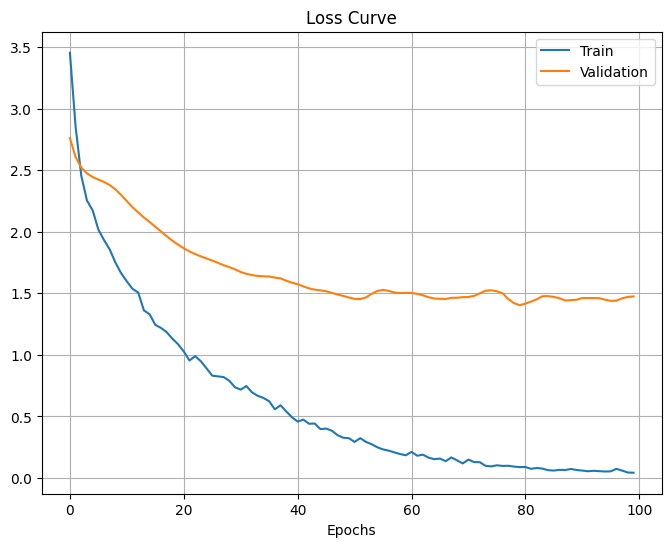

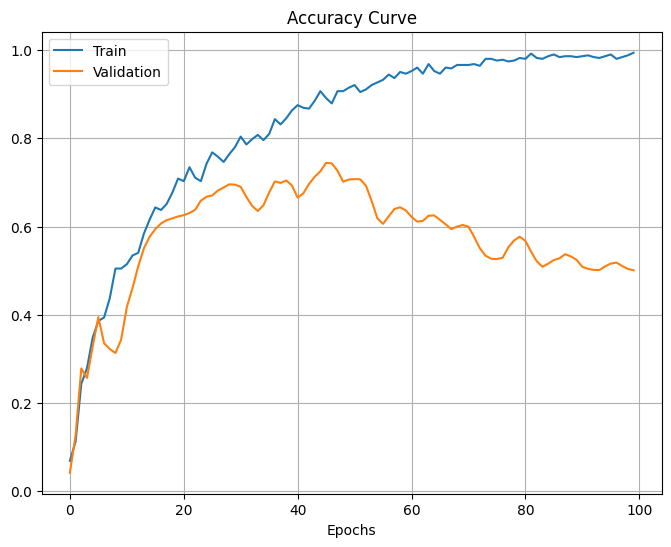

305/305 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 239ms/step
DONE.
ZIP FILE: LhSSN_SA_Module_Output.zip


In [11]:
import time

model.compile(loss='categorical_crossentropy',
                  optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  metrics=['accuracy'])

# ===============================================================
# TRAIN
# ==============================================================

tic = time.time()

history = model.fit(
    Xtrain, ytrain_cat,
    validation_data=(Xtest, ytest_cat),
    epochs=epochs,
    batch_size=batch_size,
    verbose=2
)

toc = time.time()

train_time = toc - tic

# Save history
np.save(results_folder+"/history.npy", history.history)

# ===============================================================
# PLOTS
# ==============================================================

def save_plot(a,b,title,name):

    plt.figure(figsize=(8,6))
    plt.plot(history.history[a], label='Train')
    plt.plot(history.history[b], label='Validation')
    plt.xlabel("Epochs")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.savefig(results_folder+"/"+name+".png", dpi=300)
    plt.show()

save_plot("loss","val_loss","Loss Curve","loss_curve")
save_plot("accuracy","val_accuracy","Accuracy Curve","accuracy_curve")

# ===============================================================
# EVALUATION
# ==============================================================

tic = time.time()

pred = model.predict(Xtest)

toc = time.time()

test_time = toc - tic

y_pred = np.argmax(pred, axis=1)

oa = accuracy_score(ytest, y_pred)
kappa = cohen_kappa_score(ytest, y_pred)

cm = confusion_matrix(ytest, y_pred)

each_acc = np.diag(cm)/cm.sum(axis=1)
aa = np.mean(each_acc)

precision, recall, f1, _ = precision_recall_fscore_support(
    ytest, y_pred, average='weighted'
)

# ===============================================================
# SAVE REPORT
# ==============================================================

with open(results_folder+"/results.txt","w") as f:

    f.write(f"Training Time: {train_time:.2f}s\n")
    f.write(f"Testing Time: {test_time:.2f}s\n")
    f.write(f"OA: {oa*100:.2f}\n")
    f.write(f"AA: {aa*100:.2f}\n")
    f.write(f"Kappa: {kappa*100:.2f}\n")
    f.write(f"Precision: {precision*100:.2f}\n")
    f.write(f"Recall: {recall*100:.2f}\n")
    f.write(f"F1-score: {f1*100:.2f}\n\n")

    f.write(classification_report(ytest, y_pred))

# ===============================================================
# CLASSIFICATION MAP
# ==============================================================

Xfull, yfull = loadData(dataset)
Xfull = applyPCA(Xfull, n_components_pca)

margin = windowSize//2
Xpad = padWithZeros(Xfull, margin)

outputs = np.zeros(yfull.shape)

patches = []
coords = []

for i in range(yfull.shape[0]):
    for j in range(yfull.shape[1]):

        if yfull[i,j] > 0:

            patch = Xpad[i:i+windowSize, j:j+windowSize]
            patches.append(patch)
            coords.append((i,j))

patches = np.array(patches)

pred = model.predict(patches, batch_size=512)
pred = np.argmax(pred, axis=1)

for (i,j),p in zip(coords,pred):
    outputs[i,j] = p+1

spectral.save_rgb(
    results_folder+"/classified_map.jpg",
    outputs.astype(int),
    colors=spectral.spy_colors
)

spectral.save_rgb(
    results_folder+"/ground_truth.jpg",
    yfull.astype(int),
    colors=spectral.spy_colors
)

# ===============================================================
# ZIP
# ==============================================================

zip_name = "LhSSN_SA_Module_Output.zip"

with zipfile.ZipFile(zip_name,'w') as zipf:
    for file in os.listdir(results_folder):
        zipf.write(results_folder+"/"+file, arcname=file)

print("DONE.")
print("ZIP FILE:", zip_name)